In [1]:
# step 1 import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
# step 2 load dataset

data = pd.read_csv("data/weather_data.csv")
# step clean column names
data.columns = data.columns.str.strip()
data.columns

data.head()

,Humidity,Wind Speed,Pressure,Rainfall,Temperature
0,65,12,1012,2.1,28
1,70,15,1008,0.0,30
2,55,8,1015,1.2,26
3,80,20,1005,5.5,32
4,60,10,1010,0.5,27


In [10]:
# step 3 separate inputs and output

X = data[['Humidity', 'Wind Speed', 'Pressure', 'Rainfall']]
y = data['Temperature']

In [11]:
# step 4 split dataset into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# step 5 choose polynomial degree

degree = 2

In [13]:
# step 6 generate polynomial features

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [14]:
# step 7 train regression model

model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
# step 8 predict temperature values

y_pred = model.predict(X_test_poly)

In [16]:
# step 9 compare actual and predicted results

results = pd.DataFrame({
    'Actual (°C)': y_test.values,
    'Predicted (°C)': y_pred
})

results

,Actual (°C),Predicted (°C)
0,30,28.790148


In [17]:
# step 10 evaluate model performance

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

C:\Users\kuros\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


(1.463740857861176, nan)

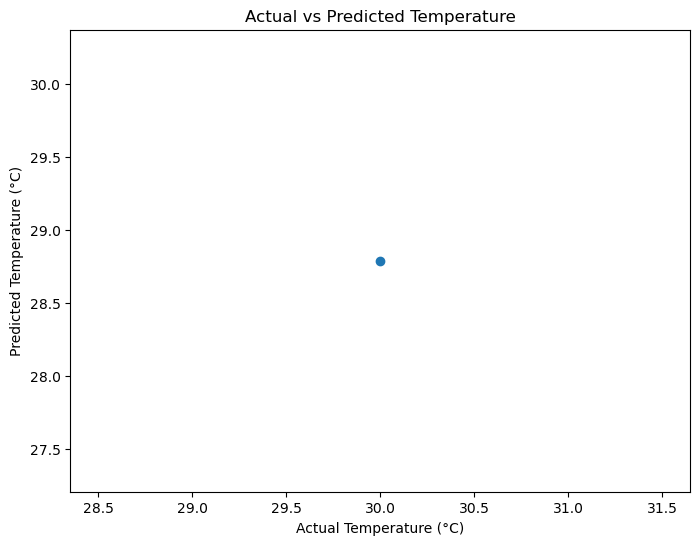

In [22]:
# step 11 visualize performance

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()